In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import scienceplots
import numpy as np

In [2]:
path = '../../../data/results/MaskRCNNFinal.pkl'

with open(path, 'rb') as f:
    data = pickle.load(f)

data = data['MaskRCNN']
f1s = data['f1s']
precisions = data['precisions']
recalls = data['recalls']
n_epochs = len(f1s)
epochs = np.arange(1, 51, 1)

In [3]:
import pandas as pd

smoothed_f1 = pd.Series(f1s).ewm(span=4, adjust=False).mean()
smoothed_p = pd.Series(precisions).ewm(span=4, adjust=False).mean()
smoothed_r = pd.Series(recalls).ewm(span=4, adjust=False).mean()

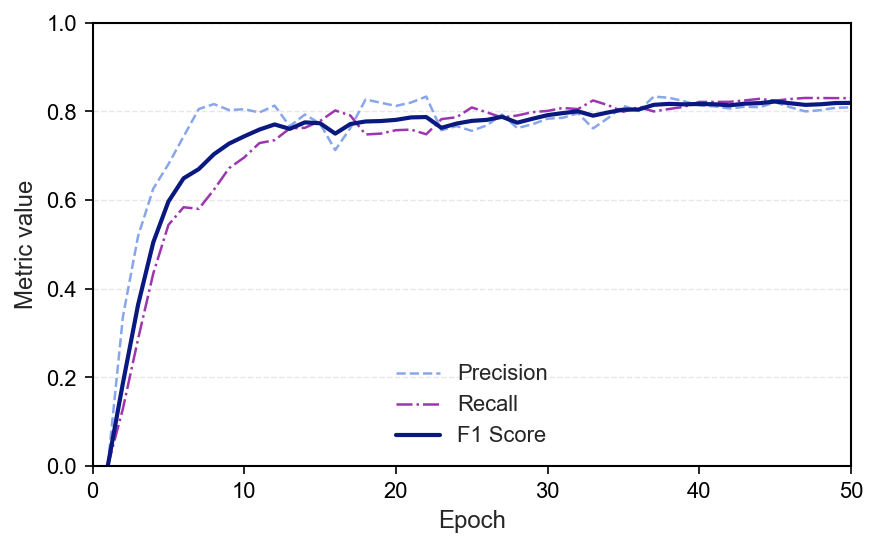

In [49]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

palette = {
    "f1": {
        "color": "#09197F",
        "linestyle": "-",
        "linewidth": 2.0,
        "alpha": 1.0
    },
    "precision": {
        "color": "#7597E7",
        "linestyle": "--",
        "linewidth": 1.2,
        "alpha": 0.85
    },
    "recall": {
        "color": "#8D12A3",
        "linestyle": "-.",
        "linewidth": 1.2,
        "alpha": 0.85
    },
}

fig, ax = plt.subplots(figsize=(6, 3.8), dpi=150)

ax.plot(epochs, smoothed_p, label="Precision", **palette["precision"])

ax.plot(epochs, smoothed_r, label="Recall",**palette["recall"])

ax.plot(epochs, smoothed_f1, label="F1 Score", **palette["f1"])

ax.set( xlabel="Epoch", ylabel="Metric value", xlim=(1, 50), ylim=(0, 1))

ax.set_xticks(np.arange(0, 51, 10))
ax.set_yticks(np.arange(0, 1.01, 0.2))


ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="x", visible=False)

ax.legend(
    frameon=False,
    loc="lower center",
    ncol=1,
)

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    bottom=True,
    left=True,
    top=False,
    right=False,
    length=4,
    width=0.8,
    color="black",
    labelcolor="black",
)

ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["top"].set_color("black")
ax.spines["right"].set_color("black")

fig.tight_layout()

plt.savefig('NonCVResults.svg', dpi=400)